In [16]:
import torch
import torch.nn as nn 
from PIL import Image
import shutil
import glob
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision.datasets import ImageFolder
from torchvision import transforms , models
from data_transform import offset_crop, LoadUint16TIff, customVal,CustomDataset, sample_gaussian_in_range, clip, gamma_enh
import os 
import numpy as np
import matplotlib.pyplot as plt 

In [15]:
import shutil
root_dir ="/home/sphere/Morpheus/new_train_DATA/Helicopter/mi28"
subdir = os.listdir(root_dir)
dst_dir ="Helicopter_mi28/train"
for i in subdir:
    ssdir = os.path.join(root_dir, i)
    image_paths = glob.glob(ssdir+'/*')
    for im_name in image_paths:
        shutil.copy2(im_name, dst_dir)


In [8]:
## Create Dataset
import glob
def rename_images(image_dir):
    image_paths = glob.glob(image_dir+'/*')
    for image in image_paths:
        basename = os.path.basename(image)
        angle = basename.split('_')[-3][2:]
        dirname = os.path.basename(image_dir)
        new_name = os.path.join(dirname+"_"+angle+".png")
        os.rename(image, os.path.join(image_dir, new_name))
    print('done')
image_dir = "/home/sphere/Morpheus/new_train_DATA/Helicopter/mi28/mi28_2sc_0.6pix"
rename_images(image_dir)

done


### HyperParameter and Directory

In [17]:
train_dir = "Bomber_fighter_dyn/train"
val_dir = "Bomber_fighter_dyn/val"
checkpoint_dir = "checkpoint_FB"

batch_size = 16
num_classes =2
num_epochs=100
learning_rate =5e-4
checkpoint_name = f"experimtent2_{num_epochs}_{batch_size}_dropout0.35_weight_decay"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# writer = SummaryWriter(f"fighter_bomber_runs/experiment2_{num_epochs}_{batch_size}_dropout0.35_weight_decay")


### Augmentation

In [18]:
def mig_aug_train(gamma_stretch = [0.5, 1], additive = [0.7, 1.5]):
    """
    Perfroms radiometric augmentation to the image. randomly assign  the parameters of the image non-linear enhancement and 
    noise floor within a limit

    Parameters
    ------------------

    gamma_stretch: limit for non linear enhancement
    additive:  limit for the noise floor 
    """
    def augmentation(img):
        arr = img.numpy()
        arr =(arr - arr.min())/(arr.max() - arr.min())
        gst = sample_gaussian_in_range(np.array(gamma_stretch).mean(), 1.5, gamma_stretch[0], gamma_stretch[1])
        add = sample_gaussian_in_range(np.array(additive).mean(), 1.5, additive[0], additive[-1])
        arr = clip(gamma_enh(arr, gst)+ np.random.gamma(add, 1/20, arr.shape), min =1 ,max = 99.25)
        if arr.ndim ==2:
            arr = np.stack([arr,arr, arr], axis = 0)
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out

    return augmentation



def tu_aug_train( paraml = [0.7, 1.1] ,g_enh = [0.35, 1], clutter = [0.7, 1.8], percentiles = [0.25, 99.5]):
    # Convert tensor image to numpy array
    def apply_gamma(img):
        arr = img.numpy()

        # normalize to 0..1 if needed
        arr /= arr.max() + 1e-8

        # gamma correction
        param = sample_gaussian_in_range((paraml[0]+paraml[1])/2, 1.5,low = paraml[0], high =paraml[-1])
        enh = sample_gaussian_in_range((g_enh[0]+g_enh[1])/2, 1.5,low= g_enh[0], high=g_enh[-1])
        cl = sample_gaussian_in_range((clutter[0]+clutter[1])/2, 1.5, clutter[0], clutter[-1])
        
        cl_denom = sample_gaussian_in_range(15,sigma=1.5,low = 10, high=20)
        
        # percentile clipping
        # lo = np.percentile(arr, minp)
        # hi = np.percentile(arr, maxp)
        # arr = np.clip(arr, lo, hi)

        # # scale 0..1
        # arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        arr = clip(gamma_enh(arr*np.random.gamma(param, 1/20),enh, arr.shape) + np.random.gamma(cl, 1/cl_denom, arr.shape))
        if arr.ndim == 2:
            arr = np.stack([arr,arr, arr], axis = 0)

        # convert back to PIL image if needed
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out

    return apply_gamma


In [19]:
## Transforms

train_class_transform = {"fighter": transforms.Compose([transforms.Lambda(offset_crop), 
                                    transforms.ToTensor(), 
                                    transforms.Lambda(mig_aug_train()),
                                    transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224,0.225])]),
                        "Tu_95": transforms.Compose([transforms.Lambda(offset_crop),
                                    transforms.ToTensor(), 
                                    transforms.Lambda(tu_aug_train()),
                                    transforms.Normalize(mean= [0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])}
val_class_transform = {"fighter": transforms.Compose([LoadUint16TIff(gamma=1, minp=0, maxp=95, img_size=128),
                                   transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225]) ]),
                        "Tu_95": transforms.Compose([LoadUint16TIff(gamma =1, minp =10, maxp = 99, img_size =128),
                                transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])])}

In [20]:
train_dataset = CustomDataset(root_dir = train_dir, class_transforms = train_class_transform)
val_dataset  = customVal(root_dir = val_dir, class_transform = val_class_transform)
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = True)

In [21]:
train_im , train_labels = next(iter(train_loader))
val_im, val_labels = next(iter(val_loader))


TypeError: pic should be PIL Image or ndarray. Got <class 'function'>

In [ ]:
train_labels, val_labels

(tensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0]),
 tensor([1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1]))

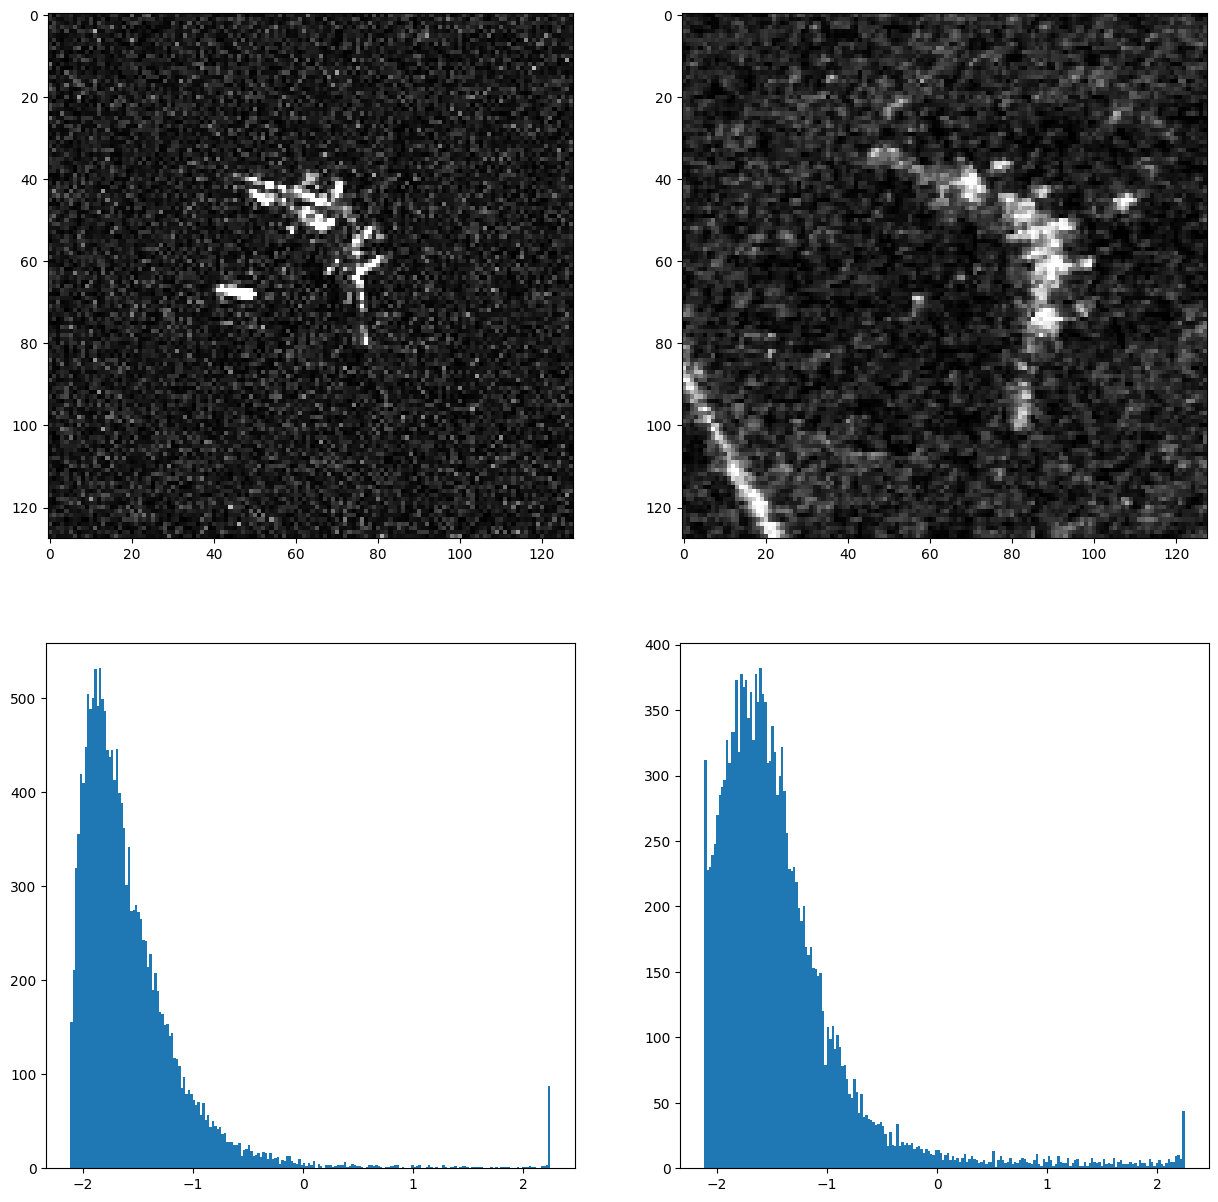

In [88]:
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].imshow(train_im[3,0], 'gray')
ax[0,1].imshow(val_im[3,0], 'gray')
ax[1,0].hist(train_im[3,0].ravel(), bins = 200)
ax[1,1].hist(val_im[3,0].ravel(), bins = 200)
plt.show()

In [89]:

model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
# adjusting the model for custom classes
for param in model.parameters():
    param.requires_grad = False
num_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(num_features, num_classes)
model.classifier[2] = nn.Dropout(p=0.35, inplace=True)
for param in model.classifier.parameters():
    param.requires_grad = True

model.to(device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

## Loss And Optimizer

In [90]:
criterion = nn.CrossEntropyLoss()
param_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(param_to_update, lr = learning_rate, weight_decay = 1e-3)

## Training loop

In [91]:
best_val_acc = 0.0
checkpoint = os.path.join(checkpoint_dir, checkpoint_name)

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    val_run_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()*images.size(0)
        _ , predicted = torch.max(output.data, 1)
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
    train_acc = 100*correct/total
    train_loss = running_loss/len(train_loader.dataset)
    writer.add_scalar("Train/Loss", train_loss, epoch)
    writer.add_scalar("Train/Accuracy", train_acc ,epoch)


    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss = criterion(outputs, labels)
            val_run_loss += v_loss.item()*images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total+=labels.size(0)
            val_correct  += (predicted==labels).sum().item()
    val_loss = val_run_loss/len(val_loader.dataset)
    val_acc = 100*val_correct/val_total
    writer.add_scalar("Val/Loss", val_loss, epoch)
    writer.add_scalar("Val/Accuracy", val_acc, epoch)

    print(f"Epoch {epoch}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train acc: {train_acc: .2f}%")
    print(f"Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc=val_acc
        torch.save(model.state_dict(), checkpoint)

print("training Complete. Best accuracy:", best_val_acc)





Epoch 0/100
Train Loss: 0.5183, Train acc:  73.61%
Val Acc: 53.85%
Epoch 1/100
Train Loss: 0.3359, Train acc:  87.50%
Val Acc: 51.28%
Epoch 2/100
Train Loss: 0.3187, Train acc:  86.81%
Val Acc: 51.28%
Epoch 3/100
Train Loss: 0.2807, Train acc:  87.96%
Val Acc: 43.59%
Epoch 4/100
Train Loss: 0.3451, Train acc:  84.95%
Val Acc: 23.08%
Epoch 5/100
Train Loss: 0.2909, Train acc:  87.73%
Val Acc: 38.46%
Epoch 6/100
Train Loss: 0.3131, Train acc:  86.34%
Val Acc: 48.72%
Epoch 7/100
Train Loss: 0.3042, Train acc:  87.27%
Val Acc: 48.72%
Epoch 8/100
Train Loss: 0.2771, Train acc:  87.96%
Val Acc: 46.15%
Epoch 9/100
Train Loss: 0.2486, Train acc:  88.89%
Val Acc: 46.15%
Epoch 10/100
Train Loss: 0.3495, Train acc:  84.26%
Val Acc: 46.15%
Epoch 11/100
Train Loss: 0.3564, Train acc:  85.19%
Val Acc: 46.15%
Epoch 12/100
Train Loss: 0.2907, Train acc:  86.11%
Val Acc: 43.59%
Epoch 13/100
Train Loss: 0.2643, Train acc:  89.58%
Val Acc: 35.90%
Epoch 14/100
Train Loss: 0.2654, Train acc:  90.97%
Val Ac